<>:465: SyntaxWarning: invalid escape sequence '\d'
<>:466: SyntaxWarning: invalid escape sequence '\p'
<>:466: SyntaxWarning: invalid escape sequence '\p'
<>:466: SyntaxWarning: invalid escape sequence '\p'
<>:466: SyntaxWarning: invalid escape sequence '\p'
<>:479: SyntaxWarning: invalid escape sequence '\p'
<>:479: SyntaxWarning: invalid escape sequence '\p'
<>:479: SyntaxWarning: invalid escape sequence '\p'
<>:479: SyntaxWarning: invalid escape sequence '\p'
<>:511: SyntaxWarning: invalid escape sequence '\p'
<>:511: SyntaxWarning: invalid escape sequence '\p'
<>:511: SyntaxWarning: invalid escape sequence '\p'
<>:511: SyntaxWarning: invalid escape sequence '\p'
<>:669: SyntaxWarning: invalid escape sequence '\p'
<>:669: SyntaxWarning: invalid escape sequence '\p'
<>:669: SyntaxWarning: invalid escape sequence '\p'
<>:669: SyntaxWarning: invalid escape sequence '\p'
<>:465: SyntaxWarning: invalid escape sequence '\d'
<>:466: SyntaxWarning: invalid escape sequence '\p'
<>:466: Synt

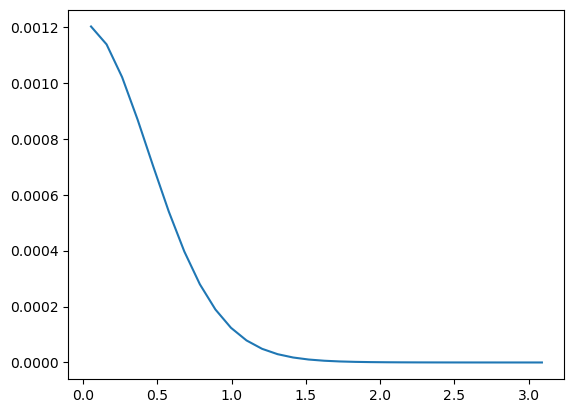

/tmp/ipykernel_173877/1326381601.py:47: RuntimeWarning: invalid value encountered in divide
  pz_Xi0=-(pz(px_A+px_chi)+2*px_chi/z-(pz_A*px_A+pz_phi*px_phi)+2*cot_x*pz_A)/z**2 # Xi0=eAchi/z**2*pz_xi
/tmp/ipykernel_173877/1326381601.py:56: RuntimeWarning: invalid value encountered in divide
  com=Xi*pz_xi/4+px_xi/z-pz(px_xi)/2+(px_A**2+px_A*px_chi+px_chi**2/2+px_phi**2/2-px_odd(px_A+px_chi))/eAchi/2
/tmp/ipykernel_173877/1326381601.py:57: RuntimeWarning: invalid value encountered in divide
  com_theta=pz_xi/2-xi/z+px_chi/eAchi/2
/tmp/ipykernel_173877/1326381601.py:58: RuntimeWarning: invalid value encountered in divide
  temp=px_xi/z**2+(3+np.exp(-chi)*V(phi)/2)/z**3+(com-cot_x*(com_theta-xi/z+3*px_A/eAchi/2)-1/eAchi)/z
/tmp/ipykernel_173877/1326381601.py:65: RuntimeWarning: invalid value encountered in divide
  temp=(pz(temp)/2-temp/z+px_odd(px_A/eAchi-xi*pz_A)/2+com+cot_x*(com_theta-xi*pz_A/2))/z
/tmp/ipykernel_173877/1326381601.py:71: RuntimeWarning: divide by zero encountered in divi

0
t --> 0.10000000000000007
time spent(min): 0.00606995423634847
1
error: 1.683384259998984e-07
error2: 5.097344461425109e-06
f3_error: 1.0132789611816406e-06


/tmp/ipykernel_173877/1326381601.py:130: RuntimeWarning: divide by zero encountered in divide
  temp=2/z*(px_f+f*px_chi)
/tmp/ipykernel_173877/1326381601.py:130: RuntimeWarning: invalid value encountered in multiply
  temp=2/z*(px_f+f*px_chi)
/tmp/ipykernel_173877/1326381601.py:135: RuntimeWarning: divide by zero encountered in divide
  temp=2/z*(pv_f+f*pv_chi)
/tmp/ipykernel_173877/1326381601.py:135: RuntimeWarning: invalid value encountered in multiply
  temp=2/z*(pv_f+f*pv_chi)


t --> 0.20000000000000015
time spent(min): 0.01129319667816162
2
error: 1.7920075611501615e-07
error2: 4.746015920274433e-06
f3_error: 7.94718817864748e-07
t --> 0.3000000000000002
time spent(min): 0.016662057240804037
3
error: 1.8260782416867395e-07
error2: 5.1142100002396594e-06
f3_error: 8.742011274875949e-07
t --> 0.4000000000000003
time spent(min): 0.021543335914611817
4
error: 2.018132751913333e-07
error2: 4.516816211650473e-06
f3_error: 1.1126869352562352e-06
t --> 0.5000000000000003
time spent(min): 0.026378854115804037
5
error: 2.3569151895852558e-07
error2: 8.18329240751463e-06
f3_error: 1.0331294415522052e-06
t --> 0.5999999999999893
time spent(min): 0.03138520320256551
6
error: 2.3265401890335616e-08
error2: 8.446954168944984e-07
f3_error: 7.948729556783718e-07
t --> 0.6999999999999783
time spent(min): 0.036220216751098634
7
error: 1.9747188134661717e-08
error2: 1.0191983175338784e-06
f3_error: 8.940588074324296e-07
t --> 0.7999999999999673
time spent(min): 0.04097329378128

In [4]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import time
import os
import my_module as my

plt.rc('font',family='Times New Roman')
plt.rc('mathtext',fontset='stix')

"""
!!! Note : 'x' in this code denotes 'theta', and the system is set in spherical topology.
--------------------------------------------
"""

def pz(field):
    return D1.dot(field)

def px(field):
    return field.dot(P1T_even)

def px_odd(field):
    return field.dot(P1T_odd)

def V(phi):
    return -6*np.cosh(phi/np.sqrt(3))-phi**4/5

def p_phi_V(phi):
    return -6/np.sqrt(3)*np.sinh(phi/np.sqrt(3))-4*phi**3/5

def evolve(evolution_fields):
    A,phi,xi3,f3=evolution_fields

    '''constrain equation to chi'''
    pz_A=pz(A)
    pz_phi=pz(phi)

    pz_chi=z/4*(pz_A**2+pz_phi**2)
    chi=D1_operator_inv.dot(np.vstack((pz_chi[:-1],np.zeros(m))))

    '''constrain equation to xi'''
    px_A=px(A)
    px_phi=px(phi)
    px_chi=px(chi)
    eAchi=np.exp(A+chi)

    pz_Xi0=-(pz(px_A+px_chi)+2*px_chi/z-(pz_A*px_A+pz_phi*px_phi)+2*cot_x*pz_A)/z**2 # Xi0=eAchi/z**2*pz_xi
    pz_Xi0[-1]=3*xi3*eAchi[-1]
    Xi=D1_operator_inv.dot(pz_Xi0)*z**2 # Xi=eAchi*pz_xi
    pz_xi=Xi/eAchi
    xi=D1_operator_inv.dot(np.vstack((pz_xi[:-1],np.zeros(m))))

    '''constrain equation to f'''
    px_xi=px_odd(xi)

    com=Xi*pz_xi/4+px_xi/z-pz(px_xi)/2+(px_A**2+px_A*px_chi+px_chi**2/2+px_phi**2/2-px_odd(px_A+px_chi))/eAchi/2
    com_theta=pz_xi/2-xi/z+px_chi/eAchi/2
    temp=px_xi/z**2+(3+np.exp(-chi)*V(phi)/2)/z**3+(com-cot_x*(com_theta-xi/z+3*px_A/eAchi/2)-1/eAchi)/z
    temp[-1]=f3
    f_tilde=D_f_tilde_operator_inv.dot(temp)
    f=1+z**2*f_tilde

    '''evolution equation to pv_A'''
    temp=f*pz_A-xi*px_A
    temp=(pz(temp)/2-temp/z+px_odd(px_A/eAchi-xi*pz_A)/2+com+cot_x*(com_theta-xi*pz_A/2))/z
    temp[-1]=0
    pv_A=D1_operator_inv.dot(temp)*z

    '''evolution equation to pv_phi'''
    temp=f*pz_phi-xi*px_phi
    temp=(pz(temp)/2-temp/z+px_odd(px_phi/eAchi-xi*pz_phi)/2-np.exp(-chi)*p_phi_V(phi)/2/z**2+cot_x*(px_phi/eAchi/2-xi*pz_phi/2))/z
    temp[-1]=0
    pv_phi=D1_operator_inv.dot(temp)*z

    '''pv_xi3 & pv_f3'''
    A3=D2[-1].dot(pz_A)/6
    phi1=pz_phi[-1]
    phi2=D1[-1].dot(pz_phi)/2
    pv_phi2=D2[-1].dot(pv_phi)/2
    pv_xi3=px(f3/3-A3-2/9*phi1*phi2)-2*cot_x*A3
    pv_f3=3/2*px_odd(xi3)+phi1*pv_phi2/6+cot_x*3*xi3/2

    constraint_fields=np.array([chi,xi,f,f_tilde])
    pv_evolution_fields=np.array([pv_A,pv_phi,pv_xi3,pv_f3],dtype=object)

    return constraint_fields,pv_evolution_fields

def RK4_evolve(evolution_fields,dt,K_return=False):
    constraint_fields,K1=evolve(evolution_fields)
    K2=evolve(evolution_fields+K1*(dt/2))[-1]
    K3=evolve(evolution_fields+K2*(dt/2))[-1]
    K4=evolve(evolution_fields+K3*dt)[-1]
    K=(K1+2*K2+2*K3+K4)/6
    evolution_fields=evolution_fields+K*dt
    global t
    t=t+dt
    if K_return:
        return constraint_fields,K,evolution_fields
    else:
        return constraint_fields,evolution_fields

def get_error(evolution_fields,constraint_fields):
    A,phi,xi3,f3=evolution_fields
    chi,xi,f,f_tilde=constraint_fields
    
    pv_A,pv_phi=pv_evolution_fields[0:2]
    pv_constraint_fields=(constraint_fields_temp[0]-8*constraint_fields_temp[1]+8*constraint_fields_temp[3]-constraint_fields_temp[4])/(12*dt)
    pv_chi,pv_xi,pv_f,pv_f_tilde=pv_constraint_fields

    eAchi=np.exp(A+chi)
    pz_A=pz(A)
    px_A=px(A)
    pz_phi=pz(phi)
    px_phi=px(phi)
    pz_chi=pz(chi)
    px_chi=px(chi)
    pz_xi=pz(xi)
    px_xi=px_odd(xi)
    pz_f=pz(f)
    px_f=px(f)
    pv_Achi=pv_A+pv_chi
    dn_A=pv_A-f*pz_A+xi*px_A
    dn_phi=pv_phi-f*pz_phi+xi*px_phi
    dn_chi=pv_chi-f*pz_chi+xi*px_chi
    dn_xi=pv_xi-f*pz_xi+xi*px_xi
    Xi=eAchi*pz_xi
    pv_Xi=eAchi*(pz_xi*pv_Achi+pz(pv_xi))

    '''evolution equation of xi'''
    temp=2/z*(px_f+f*px_chi)
    temp[-1]=0
    error=temp+px(2*xi*Xi-pz_f+f*(pz_A+pz_chi)-pv_Achi)-xi*px_odd(Xi+px_A+px_chi)+px_A*dn_A+px_phi*dn_phi+pv_Xi+cot_x*(xi*(Xi-3*px_A+px_chi)+2*f*pz_A-2*pv_A)-2*xi

    '''evolution equation of f'''
    temp=2/z*(pv_f+f*pv_chi)
    temp[-1]=0
    error2=px_odd(px_f/eAchi-pz(f*xi)+xi**2*Xi-xi*(dn_A+dn_chi)-2*dn_xi)-px_xi*pv_Achi-temp-pv_A*dn_A-pv_phi*dn_phi+xi*pv_Xi+cot_x*(xi**2*(Xi-(px_A+px_chi))+xi*(f*(pz_A+pz_chi)-2*pv_chi-2*px_xi-pz_f)+f*pz_xi-2*pv_xi+px_f/eAchi)

    print('error:',np.abs(error).max())
    print('error2:',np.abs(error2).max())
    # print('xi3_error:',np.abs(xi3-D1[-1].dot(D2).dot(xi)/6).max())
    print('f3_error:',np.abs(f3-D1[-1].dot(D2).dot(f)/6).max())
    # print('f3_error2:',np.abs(z**2*D1.dot(f_tilde)+2*z*f_tilde-D1.dot(f)).max())
    # print('f3_f_tilde_error:',np.abs(f3-D1[-1].dot(f_tilde)).max())

    return error,error2

""" Spectrum
--------------------------------------------
"""
N=50
z0,D1,D2=my.chebyshev_spectrum(N,0,1.1)
m=30
M=2*m
length=2*np.pi
x0_full,P1,P2,P3=my.fourier_spectrum(M,-length/2+length/2/M,length)
x0=x0_full[m:]
P1T=P1.T
P2T=P2.T
P1T_even=P1T[m-1::-1,m:]+P1T[m:,m:]
P1T_odd=-P1T[m-1::-1,m:]+P1T[m:,m:]
z=z0[:,None]
cot_x=1/np.tan(x0)

D1_operator=np.vstack((D1[:-1],np.eye(N)[-1]))
D1_operator_inv=np.linalg.inv(D1_operator)

D_f_tilde_operator=-np.diag(1/z0)+D1
D_f_tilde_operator[-1]=D1[-1]
D_f_tilde_operator_inv=np.linalg.inv(D_f_tilde_operator)

""" Evolution configuration
--------------------------------------------
"""
dt=0.0005 # 单次演化时间步长
interval_times=200 # 每隔多少步存一次数据
t_count=500+1 # 时间方向上存储数据的数量，+1是因为要存储初值
evolution_times=(t_count-1)*interval_times # 总共的演化次数
time_array=np.arange(t_count)*interval_times*dt # 最终输出的时间数组

""" Initial value
--------------------------------------------
"""
chi=np.full((t_count,N,m),np.nan)
xi=np.full((t_count,N,m),np.nan)
f=np.full((t_count,N,m),np.nan)
f_tilde=np.full((t_count,N,m),np.nan)
A=np.full((t_count,N,m),np.nan)
phi=np.full((t_count,N,m),np.nan)
xi3=np.full((t_count,m),np.nan)
f3=np.full((t_count,m),np.nan)
evolution_fields=np.full(t_count,np.nan,dtype=object)
constraint_fields=np.full((t_count,4,N,m),np.nan)
constraint_fields_temp=np.full((5,4,N,m),np.nan)
error=np.full((t_count,N,m),np.nan)
error2=np.full((t_count,N,m),np.nan)

phi1=0
index=120
index_temp=118
file_location_solution=f'../static_solution/BS/EOS/source={phi1}/{z0[0]}_{index}/{N=}'
#static_solution=np.load(file_location_solution+'/1.data/1.static_solution.npy')[index_temp]

A[0]=np.zeros((N,m))
phi0=0.001
phi[0]=phi0*z**2*np.exp(-10*np.sin(np.pi/length*x0)**2)
xi3[0]=np.zeros(m)
f3[0]=np.zeros(m)-2
evolution_fields[0]=np.array([A[0],phi[0],xi3[0],f3[0]],dtype=object)

plt.plot(x0,phi[0][0])
plt.show()
plt.close()

""" Evolution
--------------------------------------------
"""
t=0
time_start=time.time()
for i in range(0,t_count):
    print(i)
    constraint_fields[i],pv_evolution_fields,evolution_fields_next=RK4_evolve(evolution_fields[i],dt,True) # 即constraint_fields_temp[2]
    constraint_fields_temp[3],evolution_fields_next=RK4_evolve(evolution_fields_next,dt)
    constraint_fields_temp[4],evolution_fields_next=RK4_evolve(evolution_fields_next,dt)

    if i > 0:
        error[i],error2[i]=get_error(evolution_fields[i],constraint_fields[i])
        if True in np.isnan(error[i]):
            i=i-1
            break

    if i < t_count-1:
        for j in range(3,interval_times-2):
            evolution_fields_next=RK4_evolve(evolution_fields_next,dt)[-1]
        constraint_fields_temp[0],evolution_fields_next=RK4_evolve(evolution_fields_next,dt)
        constraint_fields_temp[1],evolution_fields[i+1]=RK4_evolve(evolution_fields_next,dt)
        print('t -->',t)

    print('time spent(min):',(time.time()-time_start)/60)

t_last=i
for i in range(0,t_last+1):
    A[i],phi[i],xi3[i],f3[i]=evolution_fields[i]
    chi[i],xi[i],f[i],f_tilde[i]=constraint_fields[i]



""" Plot
--------------------------------------------
"""
plt.plot(time_array,phi[:,0,0])
plt.show()
plt.close()









""" Test
--------------------------------------------
"""
def horizon_condition(h,f,chi,xi,A):
    eAchi=np.exp(A+chi)
    px_h=h.dot(P1T_even)
    interp_h=my.chebyshev_interp(h,z0,Warn=False)
    f_h=np.array([interp_h[i].dot(f[:,i]) for i in range(0,m)])
    xi_h=np.array([interp_h[i].dot(xi[:,i]) for i in range(0,m)])
    eAchi_h=np.array([interp_h[i].dot(eAchi[:,i]) for i in range(0,m)])

    return (xi_h+px_h/eAchi_h).dot(P1T_odd)+cot_x*(xi_h+px_h/eAchi_h)+(f_h-px_h**2/eAchi_h)/h

# t_last=t_count-1
# file_location=f'./data/normal_low_order/source={phi1}_{z0[0]}/{N=}_{m=}_{dt=}_{t_last}'
# evolution_fields=np.load(file_location+'/1.data/evolution_fields.npy',allow_pickle=True)
# constraint_fields=np.load(file_location+'/1.data/constraint_fields.npy')
# for i in range(0,t_last+1):
#     A[i],phi[i],xi3[i],f3[i]=evolution_fields[i]
#     chi[i],xi[i],f[i],f_tilde[i]=constraint_fields[i]

h=np.full((t_count,m),np.nan)
h[-1]=np.ones(m)
for i in range(0,t_last+1):
    h[i]=scipy.optimize.root(horizon_condition,h[i-1],(f[i],chi[i],xi[i],A[i])).x
    print(np.abs(horizon_condition(h[i],f[i],chi[i],xi[i],A[i])).max())

file_location=f'./data/normal_low_order/source={phi1}_{z0[0]}/n={index_temp}_gaussian/{N=}_{m=}_{dt=}_{t_last}_{phi0=}'
os.makedirs(file_location+'/1.data',exist_ok=True)
os.makedirs(file_location+'/2.picture',exist_ok=True)

plt.plot(x0,h[t_last])
plt.xlabel('$x$')
plt.ylabel('$h$')
plt.savefig(file_location+f'/2.picture/h_x_t={t_last*0.1}.png')
plt.show()
plt.close()

fig=plt.figure()
ax=fig.add_subplot(projection='3d')
X,T=np.meshgrid(x0,time_array[0:t_last+1])
ax.plot_surface(X,T,h[0:t_last+1],cmap='rainbow')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('$h$')
ax.view_init(None,60)
plt.savefig(file_location+'/2.picture/h.png')
plt.show()
plt.close()

plt.plot(time_array,(2*np.pi/h**2*np.sin(x0)).sum(axis=1)*np.pi/m/2)
plt.xlabel('$t$')
plt.ylabel('$s$')
plt.savefig(file_location+'/2.picture/s.png')
plt.show()
plt.close()

""" Plot
--------------------------------------------
"""
# file_location=f'./data/normal_low_order/source={phi1}_{z0[0]}/{N=}_{m=}_{dt=}_{t_last}'
# os.makedirs(file_location+'/1.data',exist_ok=True)
# os.makedirs(file_location+'/2.picture',exist_ok=True)

plt.plot(z0,f[t_last])
plt.xlabel('$z$')
plt.ylabel('$f$')
plt.savefig(file_location+f'/2.picture/f_z_t={t_last*0.1}.png')
plt.show()
plt.close()

plt.plot(x0,f[t_last].T)
plt.xlabel('$x$')
plt.ylabel('$f$')
plt.savefig(file_location+f'/2.picture/f_x_t={t_last*0.1}.png')
plt.show()
plt.close()

plt.plot(z0,error[t_last])
plt.xlabel('$z$')
plt.ylabel('error')
plt.savefig(file_location+f'/2.picture/error_z_t={t_last*0.1}.png')
plt.show()
plt.close()

plt.plot(x0,error[t_last].T)
plt.xlabel('$x$')
plt.ylabel('error')
plt.savefig(file_location+f'/2.picture/error_x_t={t_last*0.1}.png')
plt.show()
plt.close()

plt.plot(z0,error2[t_last])
plt.xlabel('$z$')
plt.ylabel('error2')
plt.savefig(file_location+f'/2.picture/error2_z_t={t_last*0.1}.png')
plt.show()
plt.close()

plt.plot(x0,error2[t_last].T)
plt.xlabel('$x$')
plt.ylabel('error2')
plt.savefig(file_location+f'/2.picture/error2_x_t={t_last*0.1}.png')
plt.show()
plt.close()

fig=plt.figure()
ax=fig.add_subplot(projection='3d')
X,Z=np.meshgrid(x0,z0)
ax.plot_surface(X,Z,f[t_last],cmap='rainbow')
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('$f$')
ax.view_init(None,60)
plt.savefig(file_location+f'/2.picture/f_t={t_last*0.1}.png')
plt.show()
plt.close()

fig=plt.figure()
ax=fig.add_subplot(projection='3d')
X,T=np.meshgrid(x0,time_array[0:t_last+1])
ax.plot_surface(X,T,f3[0:t_last+1],cmap='rainbow')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('$f_3$')
ax.view_init(None,60)
plt.savefig(file_location+'/2.picture/f3.png')
plt.show()
plt.close()

fig=plt.figure()
ax=fig.add_subplot(projection='3d')
X,T=np.meshgrid(x0,time_array[0:t_last+1])
ax.plot_surface(X,T,error[0:t_last+1,0],cmap='rainbow')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('error_H')
ax.view_init(None,60)
plt.savefig(file_location+'/2.picture/error_H.png')
plt.show()
plt.close()

fig=plt.figure()
ax=fig.add_subplot(projection='3d')
X,T=np.meshgrid(x0,time_array[0:t_last+1])
ax.plot_surface(X,T,error[0:t_last+1,-1],cmap='rainbow')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('error_B')
ax.view_init(None,60)
plt.savefig(file_location+'/2.picture/error_B.png')
plt.show()
plt.close()

fig=plt.figure()
ax=fig.add_subplot(projection='3d')
X,T=np.meshgrid(x0,time_array[0:t_last+1])
ax.plot_surface(X,T,error2[0:t_last+1,0],cmap='rainbow')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('error2_H')
ax.view_init(None,60)
plt.savefig(file_location+'/2.picture/error2_H.png')
plt.show()
plt.close()

fig=plt.figure()
ax=fig.add_subplot(projection='3d')
X,T=np.meshgrid(x0,time_array[0:t_last+1])
ax.plot_surface(X,T,error2[0:t_last+1,-1],cmap='rainbow')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('error2_B')
ax.view_init(None,60)
plt.savefig(file_location+'/2.picture/error2_B.png')
plt.show()
plt.close()

""" Save data
--------------------------------------------
"""
np.save(file_location+'/1.data/time_array.npy',time_array)
np.save(file_location+'/1.data/constraint_fields.npy',constraint_fields)
np.save(file_location+'/1.data/evolution_fields.npy',evolution_fields)
np.save(file_location+'/1.data/error.npy',error)
np.save(file_location+'/1.data/error2.npy',error2)
np.save(file_location+'/1.data/h.npy',h)

""" Plot
--------------------------------------------
"""
t_last=t_count-1
file_location=f'./data/normal_low_order/source={phi1}_{z0[0]}/n={index_temp}_gaussian/{N=}_{m=}_{dt=}_{t_last}_{phi0=}'

constraint_fields=np.load(file_location+'/1.data/constraint_fields.npy')
evolution_fields=np.load(file_location+'/1.data/evolution_fields.npy',allow_pickle=True)
h=np.load(file_location+'/1.data/h.npy')

os.makedirs(file_location+'/picture',exist_ok=True)

plt.plot(x0_full,np.hstack(((phi0*z**2*np.exp(-10*np.sin(np.pi/length*x0)**2))[0,::-1],(phi0*z**2*np.exp(-10*np.sin(np.pi/length*x0)**2))[0])))
plt.xlabel(r'$\theta$',fontsize=12)
plt.ylabel('$\delta\phi$',fontsize=12)
plt.xticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi],['$-\pi$','$-\pi/2$','$0$','$\pi/2$','$\pi$'],fontsize=12)
plt.savefig(file_location+f'/picture/perturbation_configuration.png',bbox_inches='tight')
plt.savefig(file_location+f'/picture/perturbation_configuration.pdf',bbox_inches='tight')
plt.show()
plt.close()

# time_index=[0,700,800,900,1000,2000]
# for index in time_index:
#     plt.plot(x0,h[index],label=f'$v={int(index*0.1)}$')
plt.plot(x0,h[0],'k',label='$v=0$')
plt.plot(x0,h[-1],label='$v=200$')
plt.xlabel(r'$\theta$',fontsize=12)
plt.ylabel('$z_h$',fontsize=12)
plt.xticks([0,np.pi/4,np.pi/2,3*np.pi/4,np.pi],['$0$','$\pi/4$','$\pi/2$','$3\pi/4$','$\pi$'],fontsize=12)
plt.legend()
plt.savefig(file_location+f'/picture/final_horizon2.png',bbox_inches='tight')
plt.savefig(file_location+f'/picture/final_horizon2.pdf',bbox_inches='tight')
plt.show()
plt.close()

plt.plot(time_array,(2*np.pi/h**2*np.sin(x0)).sum(axis=1)*np.pi/m/2)
plt.xlabel('$v$',fontsize=12)
plt.ylabel(r'$\bar{s}$',fontsize=12)
plt.savefig(file_location+'/picture/average_entropy_density.png',bbox_inches='tight')
plt.savefig(file_location+'/picture/average_entropy_density.pdf',bbox_inches='tight')
plt.show()
plt.close()

plt.plot(time_array,(2*np.pi/h**2*np.sin(x0)).sum(axis=1)*np.pi/m*2*np.pi)
plt.xlabel('$v$',fontsize=12)
plt.ylabel('$S$',fontsize=12)
plt.savefig(file_location+'/picture/total_entropy.png',bbox_inches='tight')
plt.savefig(file_location+'/picture/total_entropy.pdf',bbox_inches='tight')
plt.show()
plt.close()

theta=np.linspace(-np.pi,np.pi,100)
h_full=np.array([my.fourier_interp(theta,x0_full,np.hstack((h[i,-1::-1],h[i]))) for i in range(0,t_last+1)])
fig=plt.figure()
ax=fig.add_subplot(projection='3d')
X,T=np.meshgrid(theta,time_array[0:500+1:1])
ax.plot_surface(T,X,h_full[0:500+1:1],cmap='coolwarm')
ax.set_xlabel('$v$',fontsize=12)
ax.set_ylabel(r'$\theta$',fontsize=12)
ax.set_zlabel('$z_h$',fontsize=12)
ax.set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi],['$-\pi$','$-\pi/2$','$0$','$\pi/2$','$\pi$'],fontsize=12)
# ax.view_init(None,30)
plt.savefig(file_location+f'/picture/damping.png')
plt.savefig(file_location+f'/picture/damping.pdf')
plt.show()
plt.close()

theta=np.linspace(0,np.pi,50)
varphi=np.linspace(0,2*np.pi,100)
x=np.outer(np.sin(theta),np.cos(varphi))
y=np.outer(np.sin(theta),np.sin(varphi))
z=np.outer(np.cos(theta),np.ones_like(varphi))
h_last_interp=my.fourier_interp(theta,x0_full,np.hstack((h[-1][-1::-1],h[-1])))
norm=plt.Normalize(vmin=h_last_interp.min(),vmax=h_last_interp.max())
cmap=plt.cm.coolwarm

def plot_horizon(ax,time_index):
    h_interp=my.fourier_interp(theta,x0_full,np.hstack((h[time_index][-1::-1],h[time_index])))
    color=np.outer(h_interp,np.ones_like(varphi))
    ax.plot_surface(x,y,z,facecolors=cmap(norm(color)),cmap=cmap)
    ax.set_aspect('equal')
    ax.view_init(elev=30)
    # 缩小坐标轴范围，也就放大了图像
    scale=0.6
    ax.set_xlim([i*scale for i in ax.get_xlim()])
    ax.set_ylim([i*scale for i in ax.get_ylim()])
    ax.set_zlim([i*scale for i in ax.get_zlim()])
    ax.set_axis_off()
    ax.set_title(f'$v={int(time_index*0.1)}$')

fig=plt.figure()
ax1=fig.add_subplot(221,projection='3d')
ax2=fig.add_subplot(222,projection='3d')
ax3=fig.add_subplot(223,projection='3d')
ax4=fig.add_subplot(224,projection='3d')
plot_horizon(ax1,0)
plot_horizon(ax2,500)
plot_horizon(ax3,1000)
plot_horizon(ax4,2000)
plt.subplots_adjust(wspace=0)
cax=fig.add_axes([0.375,1,0.3,0.025])
fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cmap),cax=cax,orientation='horizontal')
plt.savefig(file_location+f'/picture/horizons_3d.png',bbox_inches='tight')
plt.savefig(file_location+f'/picture/horizons_3d.pdf',bbox_inches='tight')
plt.show()
plt.close()



theta=np.linspace(0,np.pi,50)
varphi=np.linspace(0,2*np.pi,100)
x=np.outer(np.sin(theta),np.cos(varphi))
y=np.outer(np.sin(theta),np.sin(varphi))
z=np.outer(np.cos(theta),np.ones_like(varphi))
h_last_interp=my.fourier_interp(theta,x0_full,np.hstack((h[-1][-1::-1],h[-1])))
norm=plt.Normalize(vmin=(2*np.pi/h_last_interp**2).min(),vmax=(2*np.pi/h_last_interp**2).max())
cmap=plt.cm.coolwarm

def plot_entropy_density(ax,time_index):
    h_interp=my.fourier_interp(theta,x0_full,np.hstack((h[time_index][-1::-1],h[time_index])))
    color=np.outer((2*np.pi/h_interp**2),np.ones_like(varphi))
    ax.plot_surface(x,y,z,facecolors=cmap(norm(color)),cmap=cmap)
    ax.set_aspect('equal')
    ax.view_init(elev=30)
    # 缩小坐标轴范围，也就放大了图像
    scale=0.6
    ax.set_xlim([i*scale for i in ax.get_xlim()])
    ax.set_ylim([i*scale for i in ax.get_ylim()])
    ax.set_zlim([i*scale for i in ax.get_zlim()])
    ax.set_axis_off()
    ax.set_title(f'$v={int(time_index*0.1)}$')

fig=plt.figure()
ax1=fig.add_subplot(221,projection='3d')
ax2=fig.add_subplot(222,projection='3d')
ax3=fig.add_subplot(223,projection='3d')
ax4=fig.add_subplot(224,projection='3d')
plot_entropy_density(ax1,0)
plot_entropy_density(ax2,500)
plot_entropy_density(ax3,1000)
plot_entropy_density(ax4,2000)
plt.subplots_adjust(wspace=0)
cax=fig.add_axes([0.375,1,0.3,0.025])
fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cmap),cax=cax,orientation='horizontal')
plt.savefig(file_location+f'/picture/entropy_density_3d.png',bbox_inches='tight')
plt.savefig(file_location+f'/picture/entropy_density_3d.pdf',bbox_inches='tight')
plt.show()
plt.close()




theta=np.linspace(-np.pi,np.pi,100)
h_initial_interp=my.fourier_interp(theta,x0_full,np.hstack((h[0][-1::-1],h[0])))
h_last_interp=my.fourier_interp(theta,x0_full,np.hstack((h[-1][-1::-1],h[-1])))
index=40

ax=plt.subplot(111,projection='polar',theta_offset=np.pi/2)
ax.plot(theta,1/h_initial_interp,'darkgrey',label='$v=0$')
ax.plot(theta,1/h_last_interp,label='$v=200$')
ax.plot([theta[index],theta[index]],[0,1/h_last_interp[index]],'o',color='grey',markersize=3)
ax.plot([theta[index],theta[index]],[0,1/h_last_interp[index]],'--',color='grey')
ax.text(theta[index],1/h_last_interp[index]/2,'$r_h$',ha='left',va='top',fontsize=12)
# ax.set_xticks([0,np.pi/2,np.pi,3*np.pi/2])
# ax.set_yticks([])
plt.legend()
ax.axis('off')
# plt.savefig(file_location+f'/picture/horizon_polar.png',bbox_inches='tight')
# plt.savefig(file_location+f'/picture/horizon_polar.pdf',bbox_inches='tight')
plt.show()
plt.close()



theta=np.linspace(-np.pi,np.pi,100)
h_initial_interp=my.fourier_interp(theta,x0_full,np.hstack((h[0][-1::-1],h[0])))
h_last_interp=my.fourier_interp(theta,x0_full,np.hstack((h[-1][-1::-1],h[-1])))
index=60

fig,ax=plt.subplots()
ax.plot(1/h_initial_interp*np.sin(theta),1/h_initial_interp*np.cos(theta),'grey',linestyle='--',label='$v=0$')
ax.plot(1/h_last_interp*np.sin(theta),1/h_last_interp*np.cos(theta),label='$v=200$')
ax.plot(1/h_last_interp[index]*np.sin(theta[index]),1/h_last_interp[index]*np.cos(theta[index]),'o',color='steelblue',markersize=3)
ax.plot([0,1/h_last_interp[index]*np.sin(theta[index])],[0,1/h_last_interp[index]*np.cos(theta[index])],':',color='steelblue')
ax.text(1/h_last_interp[index]*np.sin(theta[index]),1/h_last_interp[index]*np.cos(theta[index])/2,'$r_h$',ha='right',va='center',fontsize=12)
# 移动坐标轴到原点
ax.spines['left'].set_position('zero')   # 左边框到原点
ax.spines['bottom'].set_position('zero') # 底边框到原点
ax.spines['right'].set_color('none')     # 隐藏右边框
ax.spines['top'].set_color('none')       # 隐藏上边框
ax.tick_params(axis='both', direction='in')
ax.set_aspect('equal')
# '''phi1=4
ax.set_xlim(-1.6,1.6)
ax.set_ylim(-1.6,1.2)
ax.set_xticks([-1.5,-1,-0.5,0.5,1,1.5])
ax.set_yticks([-1.5,-1,-0.5,0.5,1])
# '''
'''phi1=4
ax.set_xlim(-4.2,4.2)
ax.set_ylim(-4.4,3.2)
ax.set_xticks([-4,-2,2,4])
ax.set_yticks([-4,-3,-2,-1,1,2,3])
'''
plt.title(r'$(r,\theta)$ plane',pad=10)
ax.legend()
plt.savefig(file_location+f'/picture/horizon_polar2.png',bbox_inches='tight')
plt.savefig(file_location+f'/picture/horizon_polar2.pdf',bbox_inches='tight')
plt.show()
plt.close()




plt.plot(x0,2*np.pi/h[0]**2,'grey',linestyle='--',label='$v=0$')
plt.plot(x0,2*np.pi/h[-1]**2,label='$v=200$')
plt.xlabel(r'$\theta$',fontsize=12)
plt.ylabel('$s$',fontsize=12)
plt.xticks([0,np.pi/4,np.pi/2,3*np.pi/4,np.pi],['$0$','$\pi/4$','$\pi/2$','$3\pi/4$','$\pi$'],fontsize=12)
plt.legend()
plt.savefig(file_location+f'/picture/final_entropy_density2.png',bbox_inches='tight')
plt.savefig(file_location+f'/picture/final_entropy_density2.pdf',bbox_inches='tight')
plt.show()
plt.close()